In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
train_data = datasets.CIFAR10(
    root = "data",
    train = True,
    download = True,
    transform = ToTensor(),
    target_transform = None)

test_data = datasets.CIFAR10(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor())

In [3]:
train_data[0]

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

In [4]:
type(train_data)

torchvision.datasets.cifar.CIFAR10

In [5]:
type(train_data[0])

tuple

In [6]:
image, label = train_data[0]

In [7]:
label

6

In [8]:
image.shape

torch.Size([3, 32, 32])

In [9]:
len(train_data)

50000

In [10]:
len(test_data)

10000

In [11]:
class_name = train_data.classes

In [12]:
class_name

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [13]:
len(class_name)

10

In [14]:
image,label = train_data[1]

In [15]:
image = image.permute(1,2,0)
image.shape

torch.Size([32, 32, 3])

Text(0.5, 1.0, 'truck')

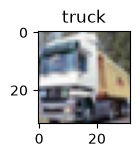

In [16]:
plt.figure(figsize=(1.2,1.2))
plt.imshow(image)
plt.title(class_name[label])

In [17]:
from torchvision import transforms

In [18]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.491,0.482,0.446],
                         std = [0.247,0.243,0.261])
])

In [19]:
train_data = datasets.CIFAR10(
    root = "data",
    train = True,
    download = True,
    transform = transform,
    target_transform = None)

test_data = datasets.CIFAR10(
    root = "data",
    train = False,
    download = True,
    transform = transform)

In [20]:
image, label = train_data[0]

In [21]:
image

tensor([[[-1.0511e+00, -1.3052e+00, -1.1940e+00,  ...,  5.2068e-01,
           4.2542e-01,  3.6191e-01],
         [-1.7338e+00, -1.9879e+00, -1.7021e+00,  ..., -3.5008e-02,
          -9.8516e-02, -5.0885e-02],
         [-1.5909e+00, -1.7338e+00, -1.2099e+00,  ..., -1.1439e-01,
          -8.2639e-02, -2.5728e-01],
         ...,
         [ 1.3145e+00,  1.2034e+00,  1.1558e+00,  ...,  5.5243e-01,
          -1.0988e+00, -1.1464e+00],
         [ 8.6997e-01,  7.5883e-01,  9.6523e-01,  ...,  9.3348e-01,
          -4.4780e-01, -6.7008e-01],
         [ 8.2234e-01,  6.7945e-01,  8.5409e-01,  ...,  1.4415e+00,
           4.0954e-01, -3.5008e-02]],

        [[-9.8297e-01, -1.2412e+00, -1.2089e+00,  ...,  1.4670e-01,
           3.3729e-02,  1.7591e-02],
         [-1.6608e+00, -1.9835e+00, -1.8544e+00,  ..., -5.6338e-01,
          -6.4407e-01, -5.7952e-01],
         [-1.5962e+00, -1.8706e+00, -1.5478e+00,  ..., -6.2794e-01,
          -6.2794e-01, -8.0545e-01],
         ...,
         [ 7.5995e-01,  4

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9084703..2.10758].


Text(0.5, 1.0, 'truck')

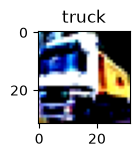

In [22]:
image,label = train_data[1]
image = image.permute(1,2,0)
image.shape
plt.figure(figsize=(1.2,1.2))
plt.imshow(image)
plt.title(class_name[label])

In [23]:
type(train_data)

torchvision.datasets.cifar.CIFAR10

In [24]:
from torch.utils.data import DataLoader

In [25]:
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,batch_size=BATCH_SIZE,shuffle=True)

test_dataloader = DataLoader(test_data,batch_size=BATCH_SIZE,shuffle=False)

In [26]:
# shuffle -> rastgele sıraya dizmeye yarar
# overffitting engeller

In [27]:
len(train_dataloader), len(test_dataloader)

(1563, 313)

In [28]:
train_dataloader.dataset[0][0].shape

torch.Size([3, 32, 32])

In [29]:
flatten_model = nn.Flatten()

first_data = train_dataloader.dataset[0][0]
flattened_data = flatten_model(first_data)

print(first_data.shape)
print(flattened_data.shape)

torch.Size([3, 32, 32])
torch.Size([3, 1024])


In [30]:
class CIFAR10Classifier(nn.Module):

    def __init__(self,input_shape:int, hidden_units:int,output_shape: int):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self,x):
        return self.layer_stack(x)

In [31]:
first_data.shape

torch.Size([3, 32, 32])

In [32]:
# input_shape -> 3*32*32

In [33]:
3*32*32

3072

In [34]:
len(class_name)

10

In [35]:
# output_shape -> 10

In [36]:
#torch.manual_seed(42)

model_0 = CIFAR10Classifier(
    input_shape=3072,
    hidden_units=32,
    output_shape=10
)

In [37]:
#model_0 = torch.compile(model_0) # ram kullanımını arttırır hızı arttırdığı için
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr = 0.01)

In [38]:
def calculate_accuracy(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct / len(y_pred))*100
    return acc

In [39]:
1563*32

50016

In [40]:
#torch.manual_seed(42)

epochs = 10

for epoch in range(epochs):

    train_loss = 0

    for batch, (X,y) in enumerate(train_dataloader):
        model_0.train()

        y_pred = model_0(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward
        optimizer.step()

        if batch % 500 ==  0:
            print(f"Batch number: {batch}")

    train_loss /= len(train_dataloader)

    test_loss = 0
    test_acc = 0

    model_0.eval()
    with torch.inference_mode():
        for X,y in test_dataloader:
            test_pred = model_0(X)
            test_loss +=loss_fn(test_pred,y)
            test_acc += calculate_accuracy(y_true=y, y_pred=test_pred.argmax(dim=1))
        test_loss /=len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"Train loss: {train_loss}, Test Loss: {test_loss}, Test Accuracy: {test_acc}")

Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 2.363811492919922, Test Loss: 2.3644325733184814, Test Accuracy: 10.413338658146964
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 2.3638784885406494, Test Loss: 2.3644325733184814, Test Accuracy: 10.413338658146964
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 2.3638312816619873, Test Loss: 2.3644325733184814, Test Accuracy: 10.413338658146964
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 2.3638699054718018, Test Loss: 2.3644325733184814, Test Accuracy: 10.413338658146964
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 2.3638081550598145, Test Loss: 2.3644325733184814, Test Accuracy: 10.413338658146964
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 2.3638670444488525, Test Loss: 2.3644325733184814, Test Accuracy: 10.413

In [41]:
def evuluate_model_performance(model : torch.nn.Module, data_loader: torch.utils.data.DataLoader,
                               loss_fn : torch.nn.Module, accuracy_function):

    loss = 0
    acc = 0

    model.eval()
    with torch.inference_mode():
        for X,y in data_loader:
            y_pred = model(X)
            loss += loss_fn(y_pred,y)
            acc += accuracy_function(y_true=y,y_pred=y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name" : model.__class__.__name__,
            "model_loss" : loss.item(),
            "model_accuracy" : acc}

In [42]:
model_0_results = evuluate_model_performance(model=model_0, data_loader=test_dataloader,
                                             loss_fn=loss_fn, accuracy_function=calculate_accuracy)

In [43]:
model_0_results

{'model_name': 'CIFAR10Classifier',
 'model_loss': 2.3644325733184814,
 'model_accuracy': 10.413338658146964}

In [44]:
class CIFAR10ClassifierNonLinear(nn.Module):

    def __init__(self,input_shape:int, hidden_units:int,output_shape: int):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self,x):
        return self.layer_stack(x)

In [45]:
#torch.manual_seed(42)

model_1 = CIFAR10ClassifierNonLinear(
    input_shape=3072,
    hidden_units=32,
    output_shape=10
)

In [46]:
#model_1 = torch.compile(model_1)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr = 0.01)

In [47]:
#torch.manual_seed(42)

epochs = 10

for epoch in range(epochs):

    train_loss = 0

    for batch, (X,y) in enumerate(train_dataloader):
        model_1.train()

        y_pred = model_1(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 500 ==  0:
            print(f"Batch number: {batch}")

    train_loss /= len(train_dataloader)

    test_loss = 0
    test_acc = 0

    model_1.eval()
    with torch.inference_mode():
        for X,y in test_dataloader:
            test_pred = model_1(X)
            test_loss +=loss_fn(test_pred,y)
            test_acc += calculate_accuracy(y_true=y, y_pred=test_pred.argmax(dim=1))
        test_loss /=len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"Train loss: {train_loss}, Test Loss: {test_loss}, Test Accuracy: {test_acc}")

Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 2.3606910705566406, Test Loss: 2.481853485107422, Test Accuracy: 30.26158146964856
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 2.306441307067871, Test Loss: 2.2138397693634033, Test Accuracy: 26.996805111821086
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 2.232715368270874, Test Loss: 2.4225571155548096, Test Accuracy: 28.69408945686901
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 2.214336633682251, Test Loss: 2.0843923091888428, Test Accuracy: 29.962060702875398
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 2.197643518447876, Test Loss: 2.112222671508789, Test Accuracy: 32.078674121405754
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 2.143596649169922, Test Loss: 2.301300048828125, Test Accuracy: 27.076677316293

In [48]:
model_1_results = evuluate_model_performance(model=model_1, data_loader=test_dataloader,
                                             loss_fn=loss_fn, accuracy_function=calculate_accuracy)

In [49]:
model_1_results

{'model_name': 'CIFAR10ClassifierNonLinear',
 'model_loss': 2.1637496948242188,
 'model_accuracy': 27.565894568690094}

In [50]:
model_0_results

{'model_name': 'CIFAR10Classifier',
 'model_loss': 2.3644325733184814,
 'model_accuracy': 10.413338658146964}

In [51]:
class CIFAR10ClassifierCNN(nn.Module):

    def __init__(self,input_shape: int, hidden_units:int, output_shape:int):
        super().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                    out_channels = hidden_units,
                    kernel_size=3,
                    stride = 1,
                    padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                    out_channels = hidden_units,
                    kernel_size=3,
                    stride = 1,
                    padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units,
                    hidden_units,
                    3,
                    padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units,
                    hidden_units,
                    3,
                    padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*8*8,
                      out_features=output_shape)
        )

    def forward(self,x):
        return self.classifier(self.block_2(self.block_1(x)))
        

In [52]:
#torch.manual_seed(42)

model_2 = CIFAR10ClassifierCNN(input_shape=3,
                               hidden_units=32,
                               output_shape=len(class_name))

In [53]:
model_2

CIFAR10ClassifierCNN(
  (block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=10, bias=True)
  )
)

In [54]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(),lr=0.01)

In [55]:
#torch.manual_seed(42)

epochs = 10

for epoch in range(epochs):

    train_loss = 0

    for batch, (X,y) in enumerate(train_dataloader):
        model_2.train()

        y_pred = model_2(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 500 ==  0:
            print(f"Batch number: {batch}")

    train_loss /= len(train_dataloader)

    test_loss = 0
    test_acc = 0

    model_2.eval()
    with torch.inference_mode():
        for X,y in test_dataloader:
            test_pred = model_2(X)
            test_loss +=loss_fn(test_pred,y)
            test_acc += calculate_accuracy(y_true=y, y_pred=test_pred.argmax(dim=1))
        test_loss /=len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"Train loss: {train_loss}, Test Loss: {test_loss}, Test Accuracy: {test_acc}")

Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.9059510231018066, Test Loss: 1.7487517595291138, Test Accuracy: 36.09225239616613
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.7670360803604126, Test Loss: 1.6947327852249146, Test Accuracy: 38.2388178913738
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.725273847579956, Test Loss: 1.6648000478744507, Test Accuracy: 38.89776357827476
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.6620762348175049, Test Loss: 1.6366435289382935, Test Accuracy: 40.22563897763578
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.6571612358093262, Test Loss: 1.6538217067718506, Test Accuracy: 40.694888178913736
Batch number: 0
Batch number: 500
Batch number: 1000
Batch number: 1500
Train loss: 1.6637285947799683, Test Loss: 1.5947134494781494, Test Accuracy: 42.29233226

In [56]:
model_2_results = evuluate_model_performance(model=model_2, data_loader=test_dataloader,
                                             loss_fn=loss_fn, accuracy_function=calculate_accuracy)

In [57]:
model_0_results

{'model_name': 'CIFAR10Classifier',
 'model_loss': 2.3644325733184814,
 'model_accuracy': 10.413338658146964}

In [58]:
model_1_results

{'model_name': 'CIFAR10ClassifierNonLinear',
 'model_loss': 2.1637496948242188,
 'model_accuracy': 27.565894568690094}

In [59]:
model_2_results

{'model_name': 'CIFAR10ClassifierCNN',
 'model_loss': 1.5578032732009888,
 'model_accuracy': 44.39896166134185}

In [60]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Logits al
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Hepsini birleştir → [N, num_classes]
    return torch.stack(pred_probs)

In [61]:
import random
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()
    
    plt.figure(figsize=(4, 4))

    # random 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # modele uygun hale getir
            img_input = img.unsqueeze(0)  
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # görseli çizmek için permute
            img_show = img.permute(1, 2, 0)

            # doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9878542..2.1226053].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8925935..1.9573283].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6036361..2.0289752].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9878542..1.281196].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8544339..1.9380295].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8767167..2.083273].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.86084..2

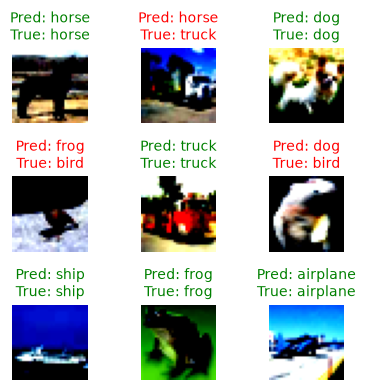

In [70]:
show_random_predictions(model_2, test_data, class_name)